**Gapminder Data Analysis and Visualization**



This notebook provides a comprehensive guide to data analysis and visualization using the Gapminder dataset.





**1- Setup and Dataset Loading**



In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set visualization styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Load the Gapminder dataset

try:
    df = pd.read_csv('gapminder.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("File not found. Loading sample data from online source...")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
display(df.head(10))

print(f"\nDataset info:")
df.info()

print(f"\nBasic statistics:")
display(df.describe())

print(f"\nMissing values:")
display(df.isnull().sum())

print(f"\nContinents distribution:")
display(df['continent'].value_counts())

Dataset loaded successfully!
Dataset shape: (142, 7)

Columns: ['Unnamed: 0', 'country', 'year', 'population', 'continent', 'life_exp', 'gdp_cap']

First few rows:


,Unnamed: 0,country,year,population,continent,life_exp,gdp_cap
0,11,Afghanistan,2007,31889923,Asia,43.828,974.580338
1,23,Albania,2007,3600523,Europe,76.423,5937.029526
2,35,Algeria,2007,33333216,Africa,72.301,6223.367465
3,47,Angola,2007,12420476,Africa,42.731,4797.231267
4,59,Argentina,2007,40301927,Americas,75.320,12779.379640
5,71,Australia,2007,20434176,Oceania,81.235,34435.367440
6,83,Austria,2007,8199783,Europe,79.829,36126.492700
7,95,Bahrain,2007,708573,Asia,75.635,29796.048340
8,107,Bangladesh,2007,150448339,Asia,64.062,1391.253792
9,119,Belgium,2007,10392226,Europe,79.441,33692.605080



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  142 non-null    int64  
 1   country     142 non-null    object 
 2   year        142 non-null    int64  
 3   population  142 non-null    int64  
 4   continent   142 non-null    object 
 5   life_exp    142 non-null    float64
 6   gdp_cap     142 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 7.9+ KB

Basic statistics:


,Unnamed: 0,year,population,life_exp,gdp_cap
count,142.000000,142.0,1.420000e+02,142.000000,142.000000
mean,857.000000,2007.0,4.402122e+07,67.007423,11680.071820
std,493.631441,0.0,1.476214e+08,12.073021,12859.937337
min,11.000000,2007.0,1.995790e+05,39.613000,277.551859
25%,434.000000,2007.0,4.508034e+06,57.160250,1624.842248
50%,857.000000,2007.0,1.051753e+07,71.935500,6124.371108
75%,1280.000000,2007.0,3.121004e+07,76.413250,18008.835640
max,1703.000000,2007.0,1.318683e+09,82.603000,49357.190170



Missing values:


,0
Unnamed: 0,0
country,0
year,0
population,0
continent,0
life_exp,0
gdp_cap,0



Continents distribution:


,count
continent,
Africa,52
Asia,33
Europe,30
Americas,25
Oceania,2




**2- Data Preprocessing and Exploration**



In [ ]:
# Create a copy for manipulation
df_clean = df.copy()

# Check for and handle missing values
if df_clean.isnull().sum().sum() > 0:
    print("Handling missing values...")
    # Fill numerical columns with median
    num_cols = ['population', 'life_exp', 'gdp_cap']
    for col in num_cols:
        if col in df_clean.columns:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # Fill categorical columns with mode
    cat_cols = ['country', 'continent']
    for col in cat_cols:
        if col in df_clean.columns:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Create additional derived features for richer analysis
print("\nCreating additional features...")
df_clean['gdp_total'] = df_clean['gdp_cap'] * df_clean['population']
df_clean['life_exp_category'] = pd.cut(df_clean['life_exp'],
                                        bins=[0, 50, 70, 90],
                                        labels=['Low', 'Medium', 'High'])
df_clean['gdp_category'] = pd.qcut(df_clean['gdp_cap'],
                                    q=3,
                                    labels=['Low', 'Medium', 'High'])
df_clean['pop_per_million'] = df_clean['population'] / 1e6

# Display updated dataframe
print("\nUpdated dataframe with new features:")
display(df_clean.head())
print(f"\nNew columns: {[col for col in df_clean.columns if col not in df.columns]}")


Creating additional features...

Updated dataframe with new features:


,Unnamed: 0,country,year,population,continent,life_exp,gdp_cap,gdp_total,life_exp_category,gdp_category,pop_per_million
0,11,Afghanistan,2007,31889923,Asia,43.828,974.580338,3.107929e+10,Low,Low,31.889923
1,23,Albania,2007,3600523,Europe,76.423,5937.029526,2.137641e+10,High,Medium,3.600523
2,35,Algeria,2007,33333216,Africa,72.301,6223.367465,2.074449e+11,High,Medium,33.333216
3,47,Angola,2007,12420476,Africa,42.731,4797.231267,5.958390e+10,Low,Medium,12.420476
4,59,Argentina,2007,40301927,Americas,75.320,12779.379640,5.150336e+11,High,High,40.301927



New columns: ['gdp_total', 'life_exp_category', 'gdp_category', 'pop_per_million']


**3. Data Visualization with Matplotlib and Seaborn**

**3.1 Distribution Plots**

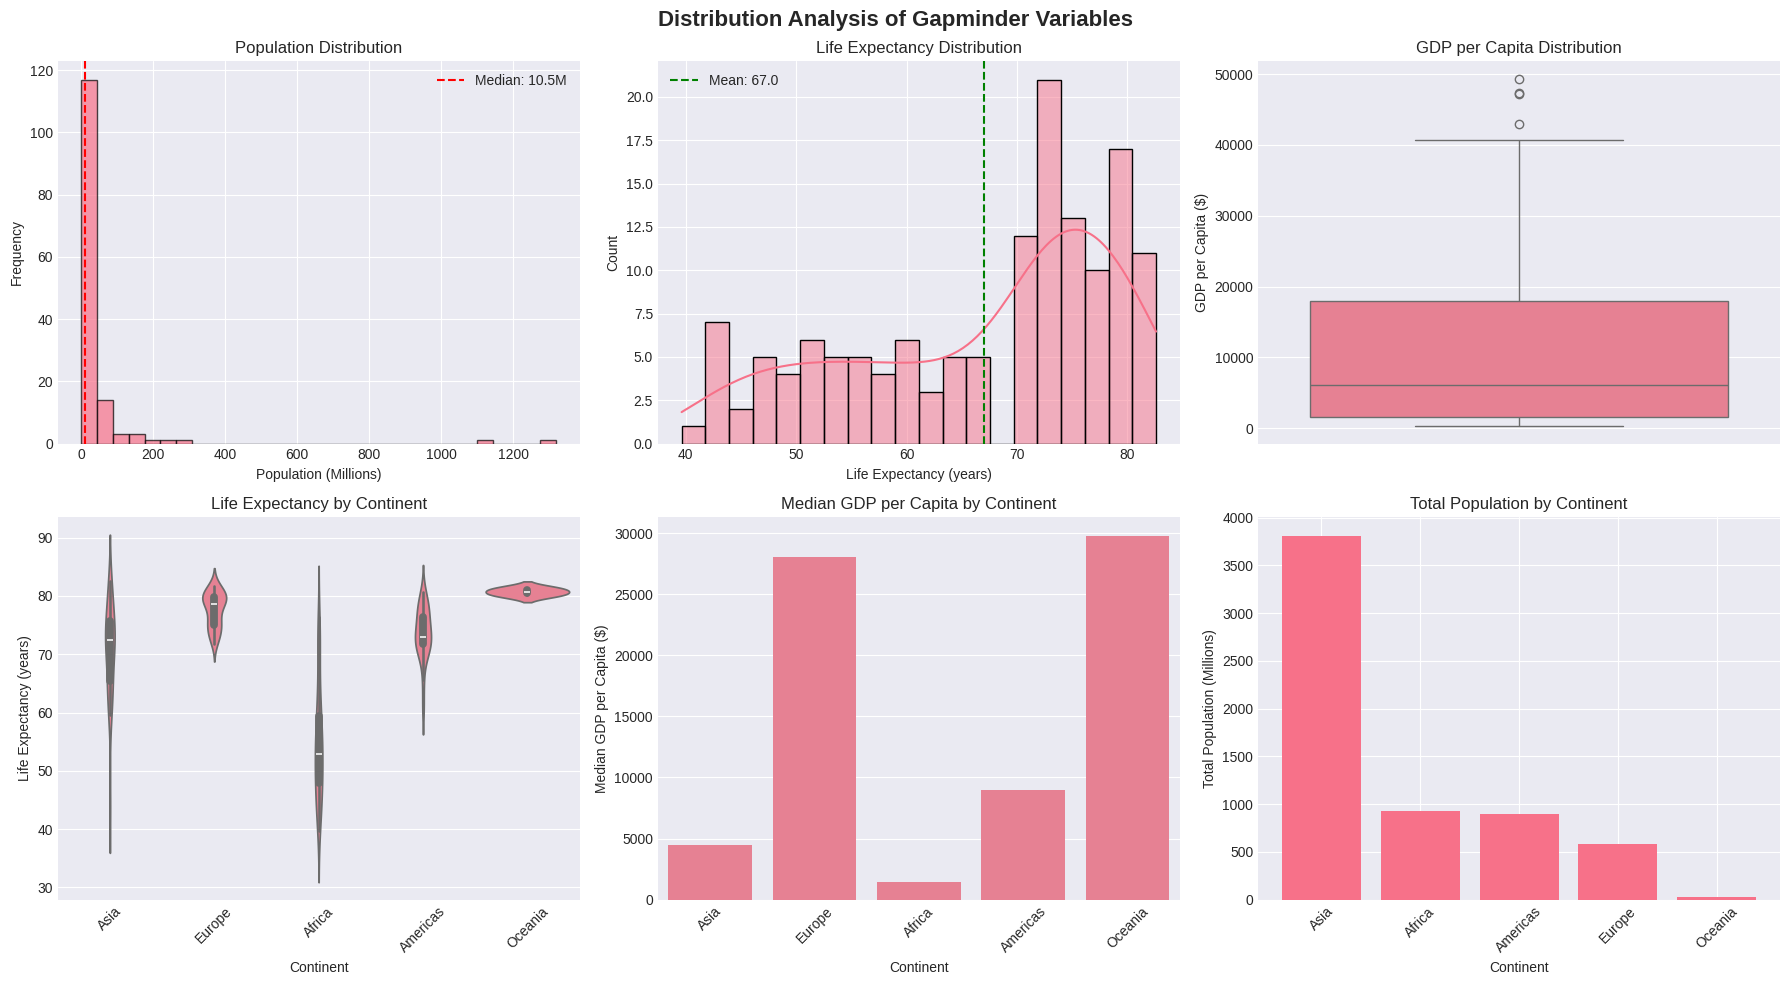

In [ ]:
# Set up figure for distribution plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution Analysis of Gapminder Variables', fontsize=16, fontweight='bold')

# Population distribution
axes[0, 0].hist(df_clean['pop_per_million'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Population (Millions)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Population Distribution')
axes[0, 0].axvline(df_clean['pop_per_million'].median(), color='red', linestyle='--',
                  label=f'Median: {df_clean["pop_per_million"].median():.1f}M')
axes[0, 0].legend()

# Life expectancy distribution
sns.histplot(data=df_clean, x='life_exp', kde=True, ax=axes[0, 1], bins=20)
axes[0, 1].set_xlabel('Life Expectancy (years)')
axes[0, 1].set_title('Life Expectancy Distribution')
axes[0, 1].axvline(df_clean['life_exp'].mean(), color='green', linestyle='--',
                  label=f'Mean: {df_clean["life_exp"].mean():.1f}')
axes[0, 1].legend()

# GDP per capita distribution
sns.boxplot(data=df_clean, y='gdp_cap', ax=axes[0, 2])
axes[0, 2].set_ylabel('GDP per Capita ($)')
axes[0, 2].set_title('GDP per Capita Distribution')

# Life expectancy by continent
sns.violinplot(data=df_clean, x='continent', y='life_exp', ax=axes[1, 0])
axes[1, 0].set_xlabel('Continent')
axes[1, 0].set_ylabel('Life Expectancy (years)')
axes[1, 0].set_title('Life Expectancy by Continent')
axes[1, 0].tick_params(axis='x', rotation=45)

# GDP by continent
sns.barplot(data=df_clean, x='continent', y='gdp_cap', estimator=np.median,
            errorbar=None, ax=axes[1, 1])
axes[1, 1].set_xlabel('Continent')
axes[1, 1].set_ylabel('Median GDP per Capita ($)')
axes[1, 1].set_title('Median GDP per Capita by Continent')
axes[1, 1].tick_params(axis='x', rotation=45)

# Population by continent
continent_pop = df_clean.groupby('continent')['pop_per_million'].sum().sort_values(ascending=False)
axes[1, 2].bar(continent_pop.index, continent_pop.values)
axes[1, 2].set_xlabel('Continent')
axes[1, 2].set_ylabel('Total Population (Millions)')
axes[1, 2].set_title('Total Population by Continent')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**3.2 Relationship Plots and Correlation Analysis**

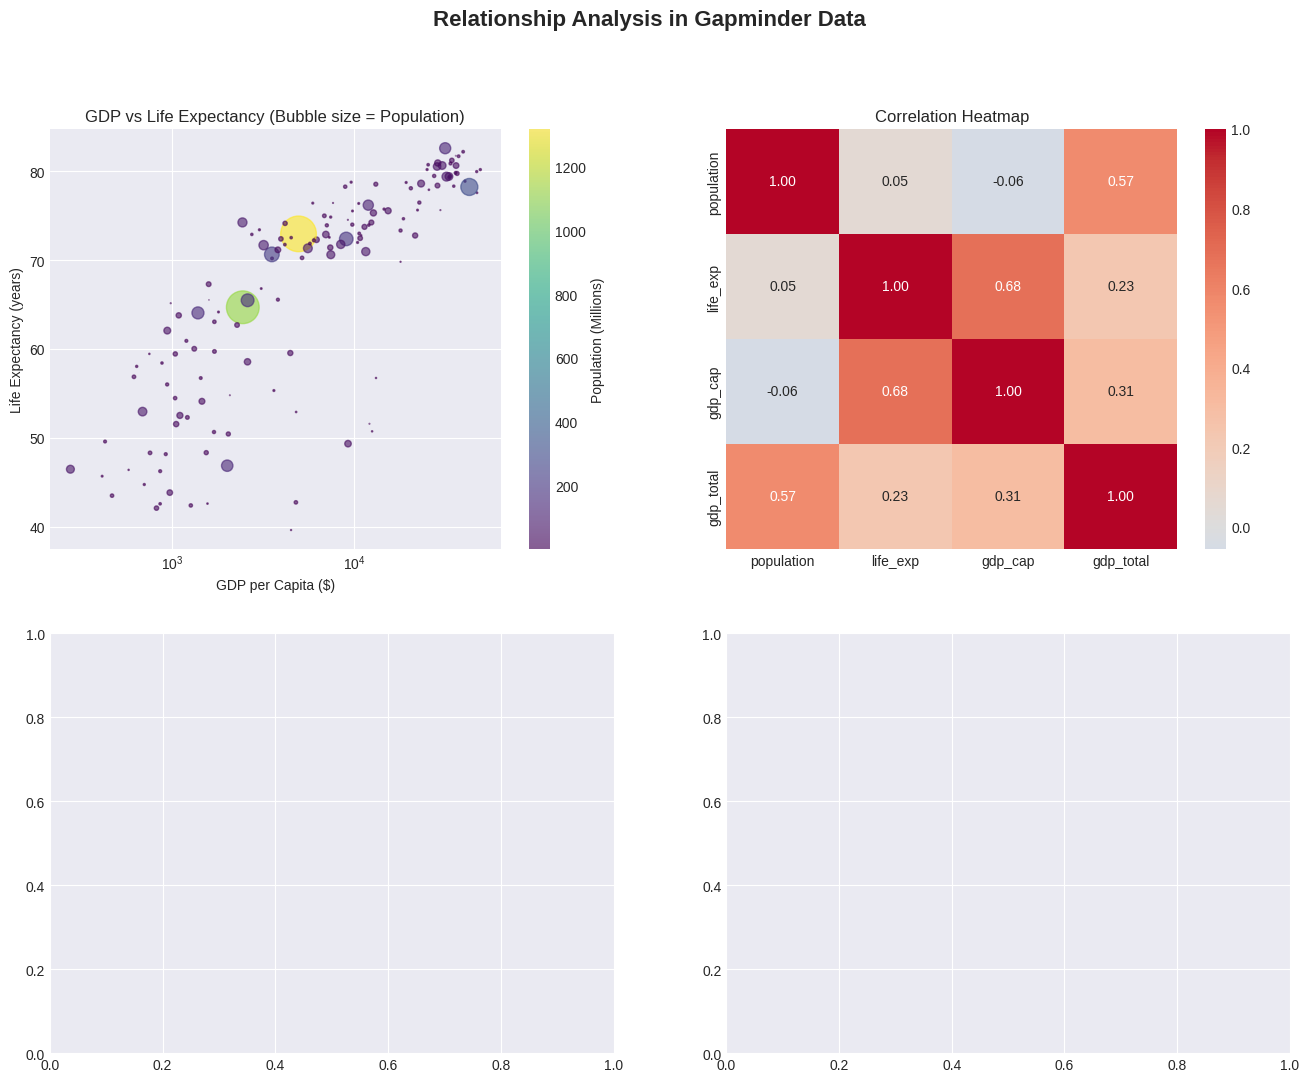

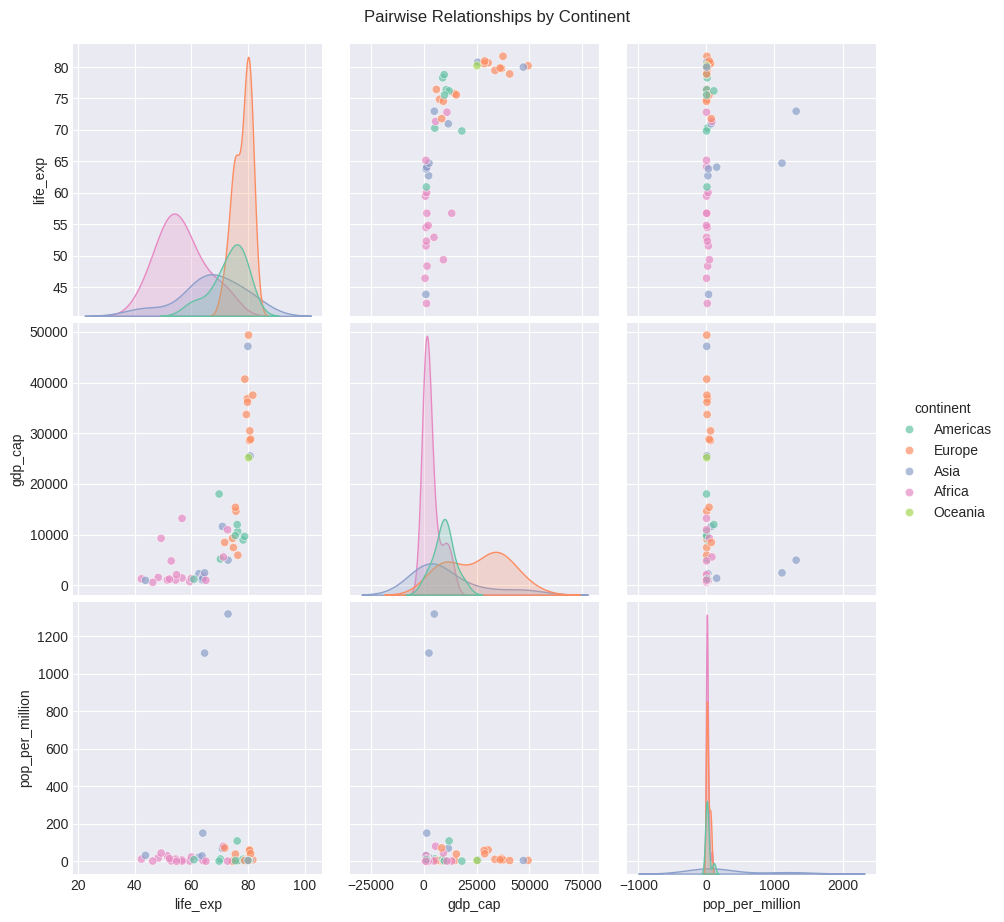

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create a figure for relationship analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Relationship Analysis in Gapminder Data', fontsize=16, fontweight='bold')

# Scatter plot: GDP vs Life Expectancy
scatter = axes[0, 0].scatter(df_clean['gdp_cap'], df_clean['life_exp'],
                            c=df_clean['pop_per_million'],
                            s=df_clean['pop_per_million']*0.5,
                            alpha=0.6, cmap='viridis')
axes[0, 0].set_xlabel('GDP per Capita ($)')
axes[0, 0].set_ylabel('Life Expectancy (years)')
axes[0, 0].set_title('GDP vs Life Expectancy (Bubble size = Population)')
axes[0, 0].set_xscale('log')  # Log scale for better visualization
plt.colorbar(scatter, ax=axes[0, 0], label='Population (Millions)')

# Correlation heatmap
corr_cols = ['population', 'life_exp', 'gdp_cap', 'gdp_total']
correlation_matrix = df_clean[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0, 1])
axes[0, 1].set_title('Correlation Heatmap')

# Pairplot for numerical variables
sample_df = df_clean.sample(min(50, len(df_clean)))
pairplot_cols = ['life_exp', 'gdp_cap', 'pop_per_million']
sns.pairplot(sample_df, vars=pairplot_cols, hue='continent', height=3,
             palette='Set2', plot_kws={'alpha': 0.7})
plt.suptitle('Pairwise Relationships by Continent', y=1.02)
plt.show()

# Continent-specific analysis
axes[1, 0].axis('off')

# Stacked bar: Life expectancy categories by continent
life_exp_pivot = pd.crosstab(df_clean['continent'], df_clean['life_exp_category'])
life_exp_pivot.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='RdYlGn')
axes[1, 1].set_xlabel('Continent')
axes[1, 1].set_ylabel('Number of Countries')
axes[1, 1].set_title('Life Expectancy Categories by Continent')
axes[1, 1].legend(title='Life Expectancy')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**4. Interactive Visualizations with Plotly**

**4.1 Interactive Scatter Plots (Advanced Analysis)**

In [ ]:
# Create interactive scatter plot
fig = px.scatter(df_clean,
                 x='gdp_cap',
                 y='life_exp',
                 size='pop_per_million',
                 color='continent',
                 hover_name='country',
                 hover_data=['gdp_total', 'year'],
                 log_x=True,
                 size_max=60,
                 title='Interactive Analysis: GDP vs Life Expectancy by Continent',
                 labels={'gdp_cap': 'GDP per Capita (log scale)',
                        'life_exp': 'Life Expectancy (years)',
                        'pop_per_million': 'Population (Millions)',
                        'continent': 'Continent'},
                 template='plotly_white')

# Add trendline for each continent
for continent in df_clean['continent'].unique():
    continent_data = df_clean[df_clean['continent'] == continent]
    fig.add_traces(px.scatter(continent_data, x='gdp_cap', y='life_exp',
                              trendline="ols", trendline_color_override="black").data[1])

fig.update_layout(
    height=600,
    showlegend=True,
    hovermode='closest',
    xaxis_title="GDP per Capita (log scale)",
    yaxis_title="Life Expectancy (years)"
)

fig.show()

# Create animated scatter plot
if 'year' in df_clean.columns and df_clean['year'].nunique() > 1:
    fig_animated = px.scatter(df_clean,
                              x='gdp_cap',
                              y='life_exp',
                              animation_frame='year',
                              size='pop_per_million',
                              color='continent',
                              hover_name='country',
                              log_x=True,
                              range_y=[df_clean['life_exp'].min()-5, df_clean['life_exp'].max()+5],
                              title='Evolution of GDP vs Life Expectancy Over Time')
    fig_animated.show()

**4.2 Interactive Dashboards and Multi-view Visualizations**

In [ ]:
# Create a dashboard with multiple interactive charts
from plotly.subplots import make_subplots

# Initialize figure with subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Life Expectancy Distribution by Continent',
                    'GDP per Capita by Country',
                    'Population vs GDP Correlation',
                    'Top 20 Countries by Life Expectancy'),
    specs=[[{"type": "box"}, {"type": "bar"}],
           [{"type": "scatter"}, {"type": "bar"}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# 1. Box plot: Life expectancy by continent
for continent in df_clean['continent'].unique():
    continent_data = df_clean[df_clean['continent'] == continent]['life_exp']
    fig.add_trace(
        go.Box(y=continent_data, name=continent, showlegend=False),
        row=1, col=1
    )

# 2. Bar plot: Top 10 countries by GDP per capita
top_gdp = df_clean.nlargest(10, 'gdp_cap')
fig.add_trace(
    go.Bar(x=top_gdp['country'], y=top_gdp['gdp_cap'],
           marker_color='lightgreen', name='GDP per Capita'),
    row=1, col=2
)

# 3. Scatter plot: Population vs GDP with continent colors
for continent in df_clean['continent'].unique():
    continent_data = df_clean[df_clean['continent'] == continent]
    fig.add_trace(
        go.Scatter(x=continent_data['pop_per_million'],
                  y=continent_data['gdp_total'],
                  mode='markers',
                  name=continent,
                  text=continent_data['country'],
                  marker=dict(size=10)),
        row=2, col=1
    )

# 4. Bar plot: Top 20 countries by life expectancy
top_life = df_clean.nlargest(20, 'life_exp')
fig.add_trace(
    go.Bar(x=top_life['country'], y=top_life['life_exp'],
           marker_color='coral', name='Life Expectancy'),
    row=2, col=2
)

# Update layout
fig.update_layout(
    height=800,
    showlegend=True,
    title_text="Gapminder Data Interactive Dashboard",
    title_font_size=20
)

# Update axis labels
fig.update_xaxes(title_text="Continent", row=1, col=1)
fig.update_yaxes(title_text="Life Expectancy (years)", row=1, col=1)
fig.update_xaxes(title_text="Country", tickangle=45, row=1, col=2)
fig.update_yaxes(title_text="GDP per Capita ($)", row=1, col=2)
fig.update_xaxes(title_text="Population (Millions)", row=2, col=1)
fig.update_yaxes(title_text="Total GDP ($)", row=2, col=1)
fig.update_xaxes(title_text="Country", tickangle=45, row=2, col=2)
fig.update_yaxes(title_text="Life Expectancy (years)", row=2, col=2)

fig.show()

**4.3 3D Interactive Visualization**

In [ ]:
# Create 3D scatter plot for multidimensional analysis
fig_3d = px.scatter_3d(df_clean,
                       x='gdp_cap',
                       y='life_exp',
                       z='pop_per_million',
                       color='continent',
                       hover_name='country',
                       size='pop_per_million',
                       size_max=30,
                       opacity=0.7,
                       title='3D Analysis: GDP, Life Expectancy, and Population',
                       labels={'gdp_cap': 'GDP per Capita',
                              'life_exp': 'Life Expectancy',
                              'pop_per_million': 'Population (Millions)'})

fig_3d.update_layout(
    scene=dict(
        xaxis_title="GDP per Capita ($)",
        yaxis_title="Life Expectancy (years)",
        zaxis_title="Population (Millions)"
    ),
    height=700,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig_3d.show()

**5. Working with Additional Datasets from Kaggle**

**5.1 Downloading and Exploring a Kaggle Dataset**

In [ ]:
# =============================================================================
# COMPREHENSIVE TITANIC DATASET ANALYSIS
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("=" * 70)
print("TITANIC DATASET ANALYSIS ASSIGNMENT")
print("=" * 70)

TITANIC DATASET ANALYSIS ASSIGNMENT


In [ ]:
# Load Titanic dataset
df_titanic = pd.read_csv('Titanic-Dataset.csv')

print("📊 STEP 1: DATA LOADING AND EXPLORATION")
print("-" * 50)

# Basic information
print(f"Dataset Shape: {df_titanic.shape}")
print(f"Columns: {list(df_titanic.columns)}")

# Display first few rows
print("\nFirst 10 rows:")
display(df_titanic.head(10))

# Dataset information
print("\n📋 Dataset Information:")
print(df_titanic.info())

# Statistical summary
print("\n📈 Statistical Summary:")
display(df_titanic.describe(include='all'))

# Missing values analysis
print("\n❓ Missing Values Analysis:")
missing_data = pd.DataFrame({
    'Missing Count': df_titanic.isnull().sum(),
    'Missing %': (df_titanic.isnull().sum() / len(df_titanic)) * 100
}).sort_values('Missing Count', ascending=False)
display(missing_data[missing_data['Missing Count'] > 0])

📊 STEP 1: DATA LOADING AND EXPLORATION
--------------------------------------------------
Dataset Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 10 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C



📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

📈 Statistical Summary:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN



❓ Missing Values Analysis:


,Missing Count,Missing %
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


5.2 Data Cleaning and Preprocessing

In [ ]:
print("\n🧹 STEP 2: DATA CLEANING AND PREPROCESSING")
print("-" * 50)

# Create a clean copy
df_clean = df_titanic.copy()

# Handle missing values
print("Handling missing values...")

# Age: Fill with median based on Pclass and Sex
df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Cabin: Create new feature indicating whether cabin info exists
df_clean['Has_Cabin'] = df_clean['Cabin'].notna().astype(int)

# Embarked: Fill with mode
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Create new features for richer analysis
print("Creating new features...")

# Family size
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

# Age groups
df_clean['AgeGroup'] = pd.cut(df_clean['Age'],
                              bins=[0, 12, 18, 35, 60, 100],
                              labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

# Fare per person
df_clean['FarePerPerson'] = df_clean['Fare'] / df_clean['FamilySize']

# Extract title from name
df_clean['Title'] = df_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df_clean['Title'] = df_clean['Title'].replace(['Lady', 'Countess', 'Capt', 'Col',
                                               'Don', 'Dr', 'Major', 'Rev', 'Sir',
                                               'Jonkheer', 'Dona'], 'Rare')
df_clean['Title'] = df_clean['Title'].replace('Mlle', 'Miss')
df_clean['Title'] = df_clean['Title'].replace('Ms', 'Miss')
df_clean['Title'] = df_clean['Title'].replace('Mme', 'Mrs')

# Check cleaned data
print("\n✅ Missing values after cleaning:")
print(df_clean.isnull().sum().sum(), "total missing values remaining")

print("\n🆕 New features created:")
new_features = [col for col in df_clean.columns if col not in df_titanic.columns]
print(new_features)

# Display cleaned data sample
print("\n📋 Cleaned data sample:")
display(df_clean[['Survived', 'Pclass', 'Sex', 'Age', 'AgeGroup',
                  'FamilySize', 'FarePerPerson', 'Title']].head())


🧹 STEP 2: DATA CLEANING AND PREPROCESSING
--------------------------------------------------
Handling missing values...
Creating new features...

✅ Missing values after cleaning:
687 total missing values remaining

🆕 New features created:
['Has_Cabin', 'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson', 'Title']

📋 Cleaned data sample:


,Survived,Pclass,Sex,Age,AgeGroup,FamilySize,FarePerPerson,Title
0,0,3,male,22.0,Young Adult,2,3.62500,Mr
1,1,1,female,38.0,Adult,2,35.64165,Mrs
2,1,3,female,26.0,Young Adult,1,7.92500,Miss
3,1,1,female,35.0,Young Adult,2,26.55000,Mrs
4,0,3,male,35.0,Young Adult,1,8.05000,Mr


**5.3 Visualization with Matplotlib/Seaborn (3+ Chart Types)**


🎨 STEP 3: VISUALIZATION WITH MATPLOTLIB/SEABORN
--------------------------------------------------


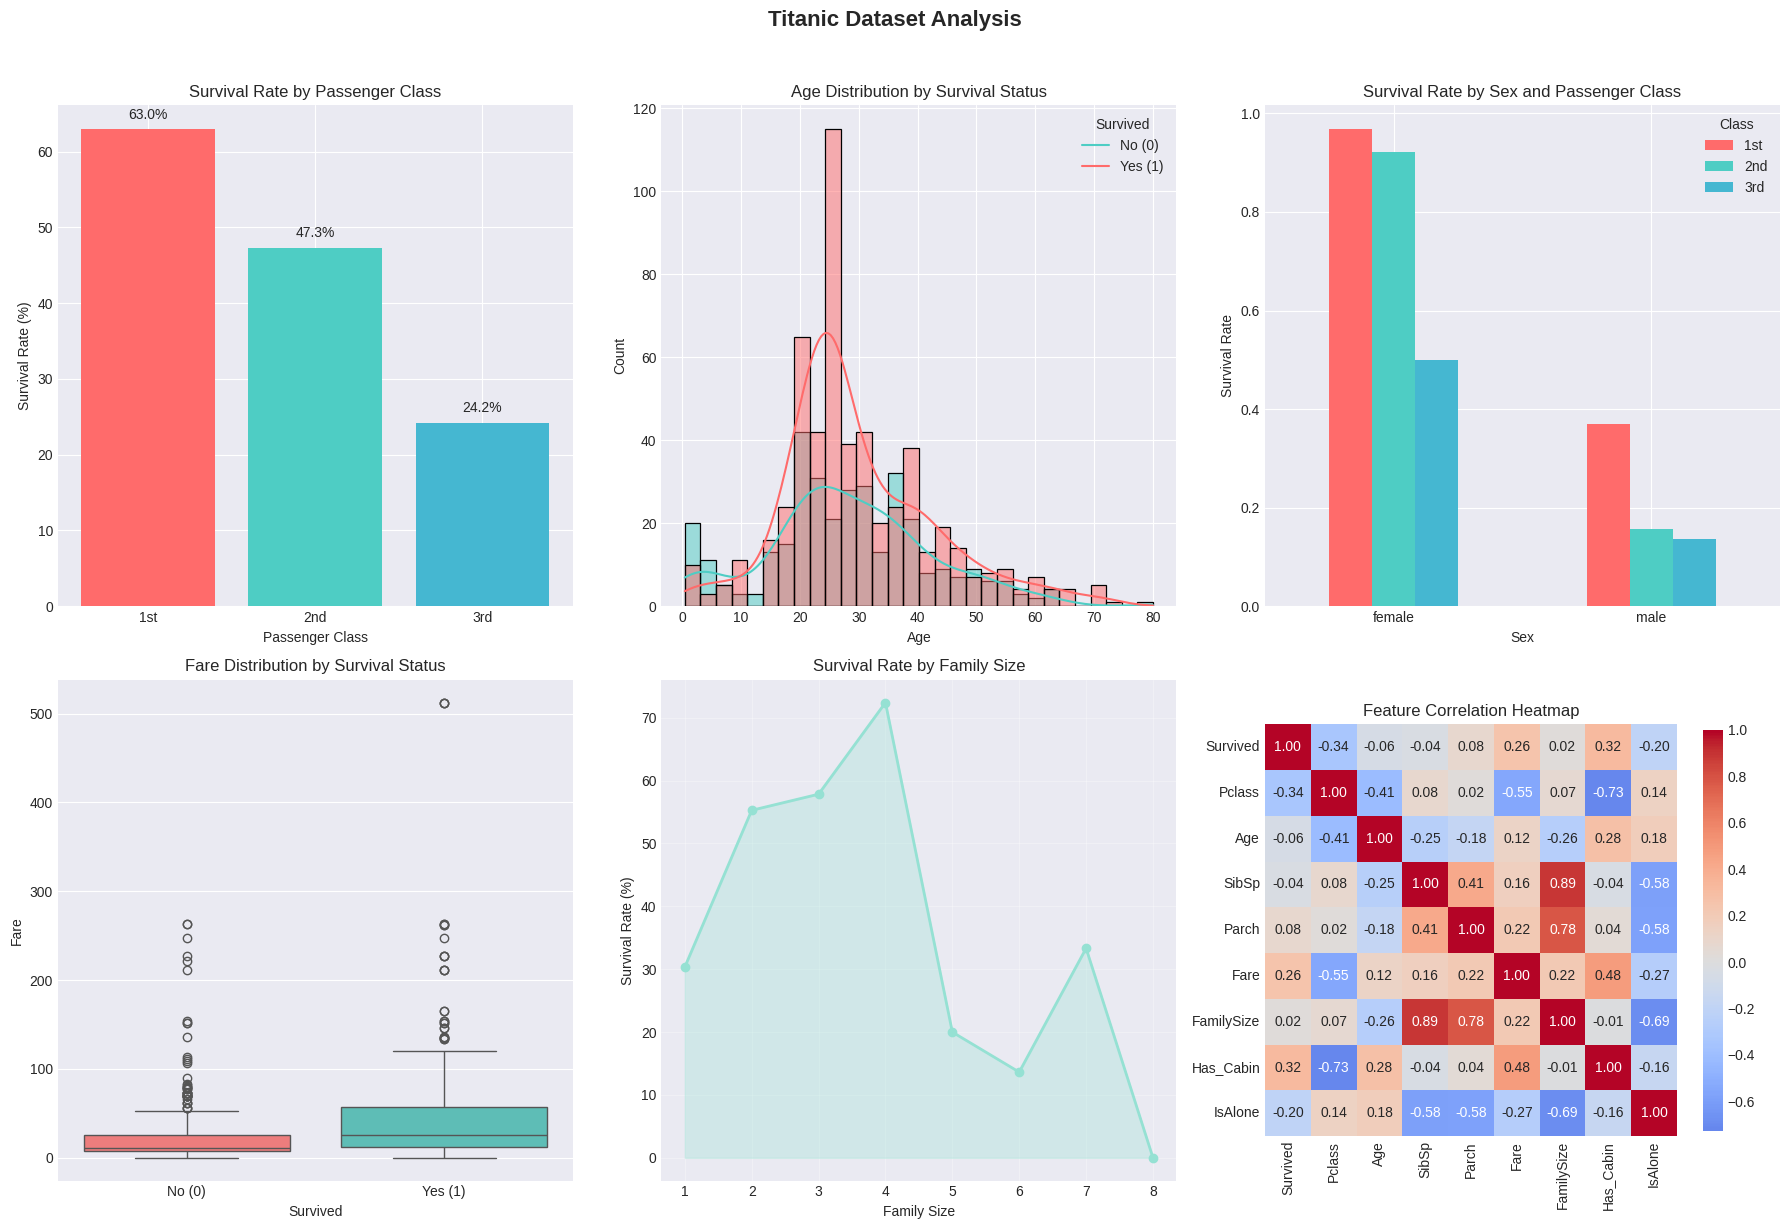


📊 Additional Analysis Visualizations:


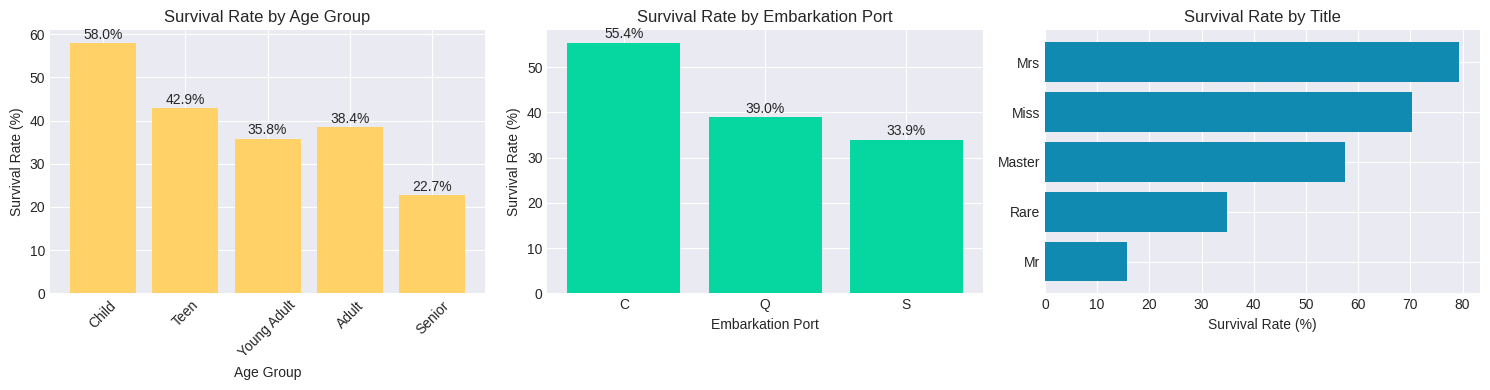

✅ Visualizations completed successfully!


In [ ]:
print("\n🎨 STEP 3: VISUALIZATION WITH MATPLOTLIB/SEABORN")
print("-" * 50)

# Set up figure for multiple visualizations
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Titanic Dataset Analysis', fontsize=16, fontweight='bold', y=1.02)

# ========== CHART 1: Survival Rate by Different Factors ==========
ax1 = plt.subplot(2, 3, 1)
survival_pclass = df_clean.groupby('Pclass')['Survived'].mean() * 100
bars = ax1.bar(survival_pclass.index, survival_pclass.values,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax1.set_xlabel('Passenger Class')
ax1.set_ylabel('Survival Rate (%)')
ax1.set_title('Survival Rate by Passenger Class')
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(['1st', '2nd', '3rd'])
# Add value labels on bars
for bar, value in zip(bars, survival_pclass.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{value:.1f}%', ha='center', va='bottom')

# ========== CHART 2: Age Distribution by Survival ==========
ax2 = plt.subplot(2, 3, 2)
# Convert Survived to string for palette mapping
df_clean['Survived_Str'] = df_clean['Survived'].map({0: '0', 1: '1'})
sns.histplot(data=df_clean, x='Age', hue='Survived_Str',
             kde=True, bins=30, ax=ax2, palette={'0': '#FF6B6B', '1': '#4ECDC4'})
ax2.set_xlabel('Age')
ax2.set_ylabel('Count')
ax2.set_title('Age Distribution by Survival Status')
ax2.legend(title='Survived', labels=['No (0)', 'Yes (1)'])

# ========== CHART 3: Survival by Sex and Class ==========
ax3 = plt.subplot(2, 3, 3)
survival_data = df_clean.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
survival_data.plot(kind='bar', ax=ax3, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax3.set_xlabel('Sex')
ax3.set_ylabel('Survival Rate')
ax3.set_title('Survival Rate by Sex and Passenger Class')
ax3.legend(title='Class', labels=['1st', '2nd', '3rd'])
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

# ========== CHART 4: Fare Distribution by Survival ==========
ax4 = plt.subplot(2, 3, 4)
# Fix: Use string keys for palette with Survived converted to string
sns.boxplot(data=df_clean, x='Survived_Str', y='Fare', ax=ax4,
            palette={'0': '#FF6B6B', '1': '#4ECDC4'})
ax4.set_xlabel('Survived')
ax4.set_ylabel('Fare')
ax4.set_title('Fare Distribution by Survival Status')
ax4.set_xticklabels(['No (0)', 'Yes (1)'])

# ========== CHART 5: Family Size Impact ==========
ax5 = plt.subplot(2, 3, 5)
family_survival = df_clean.groupby('FamilySize')['Survived'].mean() * 100
# Filter to reasonable family sizes for better visualization
family_survival = family_survival[family_survival.index <= 8]
ax5.plot(family_survival.index, family_survival.values,
         marker='o', linewidth=2, color='#95E1D3')
ax5.fill_between(family_survival.index, family_survival.values,
                 alpha=0.3, color='#95E1D3')
ax5.set_xlabel('Family Size')
ax5.set_ylabel('Survival Rate (%)')
ax5.set_title('Survival Rate by Family Size')
ax5.grid(True, alpha=0.3)

# ========== CHART 6: Correlation Heatmap ==========
ax6 = plt.subplot(2, 3, 6)
# Select numerical columns for correlation
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
                  'FamilySize', 'Has_Cabin', 'IsAlone']
correlation_matrix = df_clean[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax6, cbar_kws={'shrink': 0.8})
ax6.set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

# Additional specialized visualizations
print("\n📊 Additional Analysis Visualizations:")

# Create a figure for survival analysis
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

# Survival by Age Group
age_group_survival = df_clean.groupby('AgeGroup')['Survived'].mean() * 100
axes2[0].bar(age_group_survival.index, age_group_survival.values, color='#FFD166')
axes2[0].set_xlabel('Age Group')
axes2[0].set_ylabel('Survival Rate (%)')
axes2[0].set_title('Survival Rate by Age Group')
axes2[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_group_survival.values):
    axes2[0].text(i, v + 1, f'{v:.1f}%', ha='center')

# Survival by Embarkation Port
embarked_survival = df_clean.groupby('Embarked')['Survived'].mean() * 100
axes2[1].bar(embarked_survival.index, embarked_survival.values, color='#06D6A0')
axes2[1].set_xlabel('Embarkation Port')
axes2[1].set_ylabel('Survival Rate (%)')
axes2[1].set_title('Survival Rate by Embarkation Port')
for i, v in enumerate(embarked_survival.values):
    axes2[1].text(i, v + 1, f'{v:.1f}%', ha='center')

# Survival by Title
title_survival = df_clean.groupby('Title')['Survived'].mean().sort_values() * 100
axes2[2].barh(range(len(title_survival)), title_survival.values, color='#118AB2')
axes2[2].set_yticks(range(len(title_survival)))
axes2[2].set_yticklabels(title_survival.index)
axes2[2].set_xlabel('Survival Rate (%)')
axes2[2].set_title('Survival Rate by Title')

plt.tight_layout()
plt.show()

# Clean up temporary column
df_clean.drop('Survived_Str', axis=1, inplace=True)
print("✅ Visualizations completed successfully!")

**5.4 Interactive Visualization with Plotly (2+ Charts)**

In [ ]:
print("\n💫 STEP 4: INTERACTIVE VISUALIZATION WITH PLOTLY")
print("-" * 50)

# ========== INTERACTIVE CHART 1: 3D Survival Analysis ==========
print("Creating 3D Interactive Survival Analysis...")

fig3d = px.scatter_3d(df_clean,
                      x='Age',
                      y='Fare',
                      z='Pclass',
                      color='Survived',
                      symbol='Sex',
                      size='FamilySize',
                      hover_name='Name',
                      hover_data=['Embarked', 'Title', 'AgeGroup'],
                      opacity=0.7,
                      title='3D Analysis: Age, Fare, Class and Survival',
                      labels={'Survived': 'Survived (1=Yes, 0=No)',
                              'Pclass': 'Passenger Class',
                              'Fare': 'Ticket Fare ($)'},
                      color_discrete_map={0: '#FF6B6B', 1: '#4ECDC4'})

fig3d.update_layout(
    scene=dict(
        xaxis_title="Age",
        yaxis_title="Fare ($)",
        zaxis_title="Passenger Class",
        zaxis=dict(tickvals=[1, 2, 3], ticktext=['1st', '2nd', '3rd'])
    ),
    height=700,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig3d.show()

# ========== INTERACTIVE CHART 2: Survival Dashboard ==========
print("Creating Interactive Survival Dashboard...")

# Prepare data for sunburst chart
sunburst_df = df_clean.copy()
sunburst_df['Survived_Label'] = sunburst_df['Survived'].map({0: 'Perished', 1: 'Survived'})

fig_sunburst = px.sunburst(sunburst_df,
                           path=['Sex', 'Pclass', 'Survived_Label'],
                           values='PassengerId',
                           color='Survived_Label',
                           color_discrete_map={'Survived': '#4ECDC4', 'Perished': '#FF6B6B'},
                           title='Passenger Distribution: Sex → Class → Survival',
                           height=600)

fig_sunburst.show()

# ========== INTERACTIVE CHART 3: Interactive Parallel Coordinates ==========
print("Creating Interactive Parallel Coordinates Plot...")

# Prepare data for parallel coordinates
parallel_df = df_clean[['Survived', 'Pclass', 'Sex', 'Age', 'Fare',
                        'FamilySize', 'Embarked', 'Title']].copy()

# Convert categorical to numeric for parallel coordinates
parallel_df['Sex_Num'] = parallel_df['Sex'].map({'male': 0, 'female': 1})
parallel_df['Embarked_Num'] = parallel_df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})
parallel_df['Title_Num'] = pd.factorize(parallel_df['Title'])[0]

fig_parallel = px.parallel_coordinates(parallel_df,
                                       color='Survived',
                                       dimensions=['Pclass', 'Sex_Num', 'Age',
                                                  'Fare', 'FamilySize', 'Embarked_Num'],
                                       labels={'Pclass': 'Class',
                                               'Sex_Num': 'Sex (0=Male,1=Female)',
                                               'Age': 'Age',
                                               'Fare': 'Fare',
                                               'FamilySize': 'Family Size',
                                               'Embarked_Num': 'Embarked',
                                               'Survived': 'Survival'},
                                       color_continuous_scale=px.colors.diverging.Tealrose,
                                       title='Parallel Coordinates: Multi-Feature Survival Analysis')

fig_parallel.update_layout(height=500)
fig_parallel.show()

# ========== INTERACTIVE CHART 4: Animated Scatter Plot ==========
print("Creating Animated Scatter Plot...")

# Create age bins for animation frames
df_clean['Age_Bin'] = pd.cut(df_clean['Age'], bins=5, labels=False)

fig_animated = px.scatter(df_clean,
                          x='Fare',
                          y='Pclass',
                          animation_frame='Age_Bin',
                          color='Survived',
                          symbol='Sex',
                          size='FamilySize',
                          hover_name='Name',
                          range_x=[0, df_clean['Fare'].quantile(0.95)],
                          range_y=[0.5, 3.5],
                          title='Animated Analysis: Fare vs Class by Age Group',
                          labels={'Survived': 'Survived',
                                  'Pclass': 'Passenger Class',
                                  'Fare': 'Ticket Fare ($)',
                                  'Age_Bin': 'Age Group'},
                          color_discrete_map={0: '#FF6B6B', 1: '#4ECDC4'})

fig_animated.update_layout(height=600)
fig_animated.show()


💫 STEP 4: INTERACTIVE VISUALIZATION WITH PLOTLY
--------------------------------------------------
Creating 3D Interactive Survival Analysis...


Creating Interactive Survival Dashboard...


Creating Interactive Parallel Coordinates Plot...


Creating Animated Scatter Plot...


**5.5 Statistical Analysis**

In [ ]:
print("\n📈 STEP 5: STATISTICAL ANALYSIS")
print("-" * 50)

# ========== Hypothesis Testing ==========
print("1. HYPOTHESIS TESTING")

# Test 1: Survival difference between males and females
male_survival = df_clean[df_clean['Sex'] == 'male']['Survived']
female_survival = df_clean[df_clean['Sex'] == 'female']['Survived']

t_stat_sex, p_value_sex = stats.ttest_ind(male_survival, female_survival, equal_var=False)
print(f"\na) Gender Survival Difference:")
print(f"   Male survival rate: {male_survival.mean()*100:.1f}%")
print(f"   Female survival rate: {female_survival.mean()*100:.1f}%")
print(f"   t-statistic: {t_stat_sex:.3f}, p-value: {p_value_sex:.6f}")
if p_value_sex < 0.05:
    print("   ✅ SIGNIFICANT: Survival rates differ significantly by gender")
else:
    print("   ❌ NOT SIGNIFICANT: No significant difference")

# Test 2: Fare difference between survivors and non-survivors
survivor_fare = df_clean[df_clean['Survived'] == 1]['Fare']
non_survivor_fare = df_clean[df_clean['Survived'] == 0]['Fare']

t_stat_fare, p_value_fare = stats.ttest_ind(survivor_fare, non_survivor_fare, equal_var=False)
print(f"\nb) Fare Difference by Survival:")
print(f"   Survivor average fare: ${survivor_fare.mean():.2f}")
print(f"   Non-survivor average fare: ${non_survivor_fare.mean():.2f}")
print(f"   t-statistic: {t_stat_fare:.3f}, p-value: {p_value_fare:.6f}")
if p_value_fare < 0.05:
    print("   ✅ SIGNIFICANT: Survivors paid significantly different fares")
else:
    print("   ❌ NOT SIGNIFICANT: No significant fare difference")

# ========== Correlation Analysis ==========
print("\n2. CORRELATION ANALYSIS")

# Calculate correlations with survival
correlation_with_survival = df_clean.select_dtypes(include=[np.number]).corr()['Survived'].sort_values(ascending=False)

print("Features most correlated with survival:")
for feature, corr in correlation_with_survival.items():
    if feature != 'Survived':
        print(f"   {feature:15} : {corr:+.3f}")

# ========== Survival Probability Analysis ==========
print("\n3. SURVIVAL PROBABILITY ANALYSIS")

# Calculate survival probabilities by different factors
factors = ['Pclass', 'Sex', 'AgeGroup', 'Embarked', 'Title', 'IsAlone']
print("Survival probabilities by factor:")

for factor in factors:
    survival_prob = df_clean.groupby(factor)['Survived'].mean().sort_values(ascending=False)
    print(f"\n{factor}:")
    for level, prob in survival_prob.items():
        print(f"   {level:15} : {prob*100:5.1f}%")

    # Chi-square test for categorical factors
    if factor in ['Pclass', 'Sex', 'Embarked']:
        contingency_table = pd.crosstab(df_clean[factor], df_clean['Survived'])
        chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_table)
        print(f"   Chi-square p-value: {p_chi:.6f}")

# ========== Predictive Power Analysis ==========
print("\n4. PREDICTIVE POWER ANALYSIS")

# Calculate information value for categorical features
from scipy.stats import entropy

def calculate_iv(feature, target):
    """Calculate Information Value for a categorical feature"""
    contingency = pd.crosstab(feature, target)
    total_pos = contingency[1].sum()
    total_neg = contingency[0].sum()

    iv = 0
    for level in contingency.index:
        pos_rate = contingency.loc[level, 1] / total_pos if total_pos > 0 else 0
        neg_rate = contingency.loc[level, 0] / total_neg if total_neg > 0 else 0

        if pos_rate > 0 and neg_rate > 0:
            woe = np.log(pos_rate / neg_rate)
            iv += (pos_rate - neg_rate) * woe

    return iv

print("Information Value (predictive power) of key features:")
for feature in ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeGroup', 'IsAlone']:
    iv = calculate_iv(df_clean[feature], df_clean['Survived'])
    print(f"   {feature:10} : IV = {iv:.3f} ({'Weak' if iv<0.02 else 'Medium' if iv<0.3 else 'Strong'} predictor)")


📈 STEP 5: STATISTICAL ANALYSIS
--------------------------------------------------
1. HYPOTHESIS TESTING

a) Gender Survival Difference:
   Male survival rate: 18.9%
   Female survival rate: 74.2%
   t-statistic: -18.672, p-value: 0.000000
   ✅ SIGNIFICANT: Survival rates differ significantly by gender

b) Fare Difference by Survival:
   Survivor average fare: $48.40
   Non-survivor average fare: $22.12
   t-statistic: 6.839, p-value: 0.000000
   ✅ SIGNIFICANT: Survivors paid significantly different fares

2. CORRELATION ANALYSIS
Features most correlated with survival:
   Has_Cabin       : +0.317
   Fare            : +0.257
   FarePerPerson   : +0.222
   Parch           : +0.082
   FamilySize      : +0.017
   PassengerId     : -0.005
   SibSp           : -0.035
   Age_Bin         : -0.036
   Age             : -0.060
   IsAlone         : -0.203
   Pclass          : -0.338

3. SURVIVAL PROBABILITY ANALYSIS
Survival probabilities by factor:

Pclass:
                 1 :  63.0%
           